In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('styleNB.mplstyle')


def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
        d_ = d_.copy().sort_values('frame')
        interval_frames = d_.frame.values[::frame_step]
        sampled = d_[d_['frame'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    df_out['interval'] = df_out['frame']

    return df_out


In [36]:
# load the new construct data
df_filtered = pd.read_csv('../../data/processed_3D_tracking/20240607_compiled_galvaninKOlines_charged-eGFPtracking.csv')
df_filtered = df_filtered[df_filtered.E_V_cm != 5]

# Include the rescue data
f_rescue_filtered = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_rescue_tracking_GFPplus.csv'
df_gfp = pd.read_csv(f_rescue_filtered)
df_gfp = df_gfp[df_gfp.E_V_cm != 5]
df_gfp = df_gfp[['cell', 'frame', 'x', 'y', 'z',
       'celltype', 'E_V_cm', 'date', 'trial', 'user']]

df = pd.concat([df_filtered, df_gfp], ignore_index = True)


In [37]:
#  Step 1: Remove cells at the periphery
df_temp_ = pd.DataFrame()
for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df = df_temp_

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 20: #14:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0], row.z.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Filter: skip low-displacement tracks (still only 2D for this filter)
    total_movement = np.sum(np.linalg.norm(np.diff(positions[:, :2], axis=0), axis=1))
    if total_movement < 15:
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1],
            'z': positions[:, 2]
        })
    ], ignore_index=True)

df_filtered_tracks.head()


,celltype,E_V_cm,date,trial,user,cell,frame,x,y,z
0,dHL60TMEM154KO-clone1+9GFP-galvanin-HA,0,20240515,1,HK,3,0,252.243925,360.130815,220.702794
1,dHL60TMEM154KO-clone1+9GFP-galvanin-HA,0,20240515,1,HK,3,1,255.418158,363.218407,218.694373
2,dHL60TMEM154KO-clone1+9GFP-galvanin-HA,0,20240515,1,HK,3,2,256.874769,369.624201,216.593420
3,dHL60TMEM154KO-clone1+9GFP-galvanin-HA,0,20240515,1,HK,3,3,257.306670,373.108395,219.479155
4,dHL60TMEM154KO-clone1+9GFP-galvanin-HA,0,20240515,1,HK,3,4,257.538843,373.167138,222.743826


In [38]:
def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr

color_dict = {'dHL60KW': '#B8BABC',
              'dHL60TMEM154KO': (1.0, 0.4980392156862745, 0.054901960784313725),
              'dHL60TMEM154KO-clone1galvanin-GFP-HA': (0.17254901960784313,  0.6274509803921569, 0.17254901960784313),
             'dHL60TMEM154KO-clone1+9GFP-galvanin-HA': (0.12156862745098039,0.4666666666666667, 0.7058823529411765),
             'dHL60TMEM154KO-clone1-30GFP-galvanin-HA': 'k'}

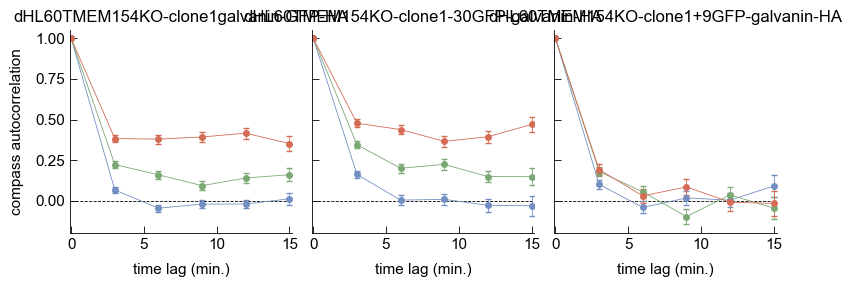

In [39]:
interval = 3
df_intervals = parse_trajectories(df_filtered_tracks, frame_step=interval)
ind_dict = dict(zip(['dHL60TMEM154KO-clone1galvanin-GFP-HA','dHL60TMEM154KO-clone1-30GFP-galvanin-HA', 'dHL60TMEM154KO-clone1+9GFP-galvanin-HA'], [0, 1, 2]))    

autocorr_list = []

for g, d in df_intervals.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * 3,  # actual lag in frames
        'autocorr': acf
    }))
    
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()


celltypes = df_avg_autocorr.celltype.unique()
fig, axes = plt.subplots(1, len(celltypes), figsize = (8,3), sharey=True)# figsize=(3*len(celltypes),3), sharey=True)

if len(celltypes) == 1:
    axes = [axes]

for ax, celltype in zip(axes, celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype==celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]  # same across lags if consistent
        axes[ind_dict[celltype]].errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})", capsize=2, marker='o', markersize = 4
        )
    axes[ind_dict[celltype]].set_title(celltype, fontsize=12)

for ax_ in axes:
    ax_.set_xlim(-0.1, 5*3+0.2)
    ax_.set_ylim(-0.2, 1.05)
    ax_.hlines(0,0,6*3, zorder = 0, color = 'k', linestyle = '--')
    ax_.set_xlabel('time lag (min.)')

axes[0].set_ylabel('compass autocorrelation')


plt.tight_layout()


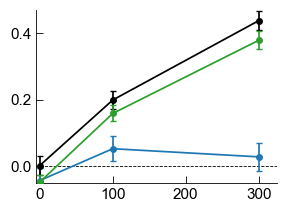

In [50]:
# Choose lag of interest (in minutes)
lag_of_interest = 6  # e.g., for 6 min
df_lag = df_autocorr[df_autocorr.lag == lag_of_interest]

# Group by condition
df_lag_stats = df_lag.groupby(['celltype', 'E_V_cm']).agg(
    mean_acf=('autocorr', 'mean'),
    sem_acf=('autocorr', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

fig, ax = plt.subplots(1, 1, figsize=(3, 2.25))

for celltype, d in df_lag_stats.groupby('celltype'):
    ax.errorbar(
        d['E_V_cm']*100, d['mean_acf'], yerr=d['sem_acf'],
        label=celltype,
        lw=1.25, marker='o', markersize=4,
        color=color_dict[celltype],  # fallback if not in dict
        zorder=10, capsize=2
    )

ax.hlines(0, 0, 100*df_lag_stats['E_V_cm'].max() + 50, color='k', linestyle='--', zorder=0)

ax.set_xlim(-0.05*100, 3.25*100)
ax.set_ylim(-0.05, 0.47)

# ax.set_xlim(-0.05, 3.5)
# ax.set_ylim(-0.05, 0.4)

# ax.set_xlabel('electric field strength (V/cm)')
# ax.set_ylabel(f'compass\nautocorrelation\n({lag_of_interest} min. time lag)')

# # Move legend outside
# box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig('../../figures/Figure6_autocorrelation_updated.pdf', bbox_inches='tight')